In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import os
from yfinance import ticker


In [2]:
def get_sp500_tickers():
    """Fetch the list of S&P 500 tickers from Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    tickers = []
    for row in table.findAll('tr')[1:]:
        ticker = row.findAll('td')[0].text.strip()
        tickers.append(ticker)
    return tickers

tickers = get_sp500_tickers()

In [3]:
import concurrent.futures
def fetch_stock_data(ticker):
    try:
        ticker_obj = yf.Ticker(str(ticker))
        ticker_hist = ticker_obj.history(period="5y")
        
        if ticker_hist.empty:
            print(f"No data on {ticker}")
            return None
        
        min_value = ticker_hist['Close'].min()
        max_value = ticker_hist['Close'].max()
        current_value = ticker_hist['Close'].iloc[-1]
        weight = max_value - min_value
        score = (max_value - current_value) / (current_value - min_value)
        
        return {
            "ticker": ticker,
            "min_val": min_value,
            "max_val": max_value,
            "current_value": current_value,
            "score": score,
            "weight": weight,
            "weighted_score": score / weight if weight != 0 else 0
        }
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

def fetch_all_stocks(tickers):
    stock_data = []
    with concurrent.futures.ThreadPoolExecutor() as executor:
        results = executor.map(fetch_stock_data, tickers)
    
    stock_data = [res for res in results if res is not None]
    return stock_data

stock_data = fetch_all_stocks(tickers)

$BF.B: possibly delisted; no price data found  (period=5y)


No data on BF.B


$BRK.B: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


No data on BRK.B


$ETR: possibly delisted; no price data found  (period=5y)


No data on ETR


$LEN: possibly delisted; no price data found  (period=5y)


No data on LEN


C:\Users\owenh\AppData\Local\Temp\ipykernel_7832\1836721875.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  score = (max_value - current_value) / (current_value - min_value)


In [4]:
df = pd.DataFrame(stock_data).sort_values(by="score")
deals = df[df["score"] >= 1]
deals.to_csv('sp500_with_scores.csv')

In [5]:
import matplotlib.pyplot as plt

# Plot histogram using Pandas
deals['score'].plot(kind='hist', bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

ValueError: autodetected range of [1.034445837157342, inf] is not finite

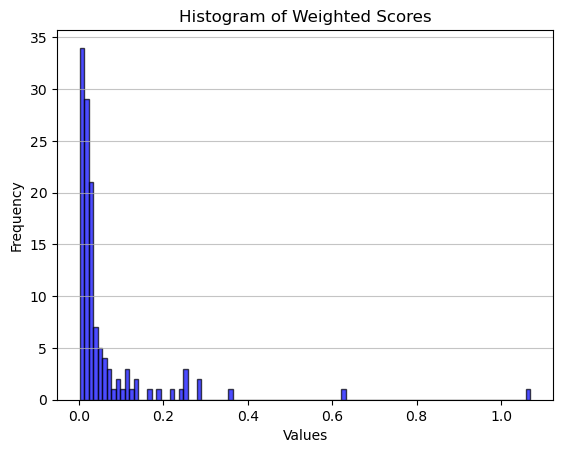

In [8]:
# Plot histogram using Pandas
deals['weighted_score'].plot(kind='hist', bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Weighted Scores')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

In [6]:
# Load the S&P 500 dataset
url = "https://datahub.io/core/s-and-p-500-companies/r/constituents.csv"  # Replace with your dataset URL or file path
df = pd.read_csv(url)

# Extract the ticker, sector, and industry columns
tickers = df['Symbol'].tolist()
sectors = df['GICS Sector'].tolist()
industries = df['GICS Sub-Industry'].tolist()

In [7]:
#Makes a df with sector and industry information
infoFrame = pd.DataFrame({
    'ticker': tickers, 
    'sector': sectors, 
    'industry': industries})

In [8]:
#Adds the industry and sector columns to the dataframe
merged_df = pd.merge(infoFrame, deals, on='ticker', how='inner')

In [9]:
#Gets dividend T/F for each stock on the narrowed ticker list (long)
with_divs = []
for x in merged_df['ticker']:
    divs = yf.Ticker(x).dividends
    
    if len(divs) > 0:
        with_divs.append(x)

In [10]:
#Adds a column that indicates if a stock has a dividend
merged_df["divs"] = merged_df['ticker'].apply(lambda x: x in with_divs)


In [11]:
#Groups stocks with a dividend by sector
grouped_sectors = {sector: group for sector, group in merged_df[merged_df['divs'] == True].groupby('sector')}

#Groups stocks with no dividend by sector
grouped_nDivs = {sector: group for sector, group in merged_df[merged_df['divs'] == False].groupby('sector')}



In [12]:
#Prints data on stocks with dividends
for sector, group in grouped_sectors.items():
    print(f"Sector: {sector}")
    print(group.drop(columns = ['sector','weight', 'weighted_score', 'divs']).sort_values(by="score" ,ascending=False))
    print()

Sector: Communication Services
    ticker                      industry    min_val     max_val  \
81    PARA        Movies & Entertainment   9.521918   90.812828   
71    MTCH  Interactive Media & Services  28.284594  174.509476   
102    DIS        Movies & Entertainment  78.352066  199.446106   
29   CMCSA             Cable & Satellite  26.823023   56.013733   

     current_value      score  
81       11.300000  44.718316  
71       34.689999  21.828358  
102     110.379997   2.780889  
29       35.389999   2.407353  

Sector: Consumer Discretionary
    ticker                             industry     min_val     max_val  \
78     NKE  Apparel, Accessories & Luxury Goods   59.454521  170.152161   
9     APTV         Automotive Parts & Equipment   33.549999  178.119995   
51       F             Automobile Manufacturers    3.268043   20.632551   
67     LVS                     Casinos & Gaming   29.224714   65.691078   
56     HAS                     Leisure Products   37.083851   91.0

In [13]:
#Prints data on stocks without dividends
for sector, group in grouped_nDivs.items():
    print(f"Sector: {sector}")
    print(group.drop(columns = ['sector','weight', 'weighted_score', 'divs']).sort_values(by="score" ,ascending=False))
    print()

Sector: Communication Services
    ticker           industry     min_val     max_val  current_value  \
103    WBD       Broadcasting    6.710000   77.269997      10.340000   
27    CHTR  Cable & Satellite  254.610001  821.010010     360.269989   

         score  
103  18.438015  
27    4.360591  

Sector: Consumer Discretionary
   ticker                        industry  min_val     max_val  current_value  \
21    CZR                Casinos & Gaming     7.10  119.489998      39.759998   
75    MHK                Home Furnishings    58.66  229.740005     121.010002   
23    KMX               Automotive Retail    44.27  154.850006      88.900002   
79   NCLH  Hotels, Resorts & Cruise Lines     7.77   52.020000      26.379999   

       score  
21  2.441213  
75  1.743865  
23  1.477706  
79  1.377754  

Sector: Consumer Staples
   ticker                             industry    min_val     max_val  \
39   DLTR  Consumer Staples Merchandise Retail  61.209999  174.080002   

    current_val

In [14]:
merged_df.to_csv('stock_and_info.csv')

In [15]:
merged_df

,ticker,sector,industry,min_val,max_val,current_value,score,weight,weighted_score,divs
0,ADBE,Information Technology,Application Software,275.200012,688.369995,460.160004,1.233834,413.169983,0.002986,True
1,AMD,Information Technology,Semiconductors,38.709999,211.380005,113.099998,1.321145,172.670006,0.007651,False
2,AES,Utilities,Independent Power Producers & Energy Traders,8.089493,26.797682,9.930000,9.164690,18.708189,0.489876,True
3,ALB,Materials,Specialty Chemicals,48.421322,317.137085,81.209999,7.195383,268.715763,0.026777,True
4,ARE,Real Estate,Office REITs,86.687798,197.903793,94.849998,12.625736,111.215996,0.113524,True
...,...,...,...,...,...,...,...,...,...,...
104,WST,Health Care,Health Care Supplies,127.436783,467.692017,214.729996,2.897843,340.255234,0.008517,True
105,WYNN,Consumer Discretionary,Casinos & Gaming,42.221642,137.401886,88.820000,1.042566,95.180244,0.010954,True
106,ZBRA,Information Technology,Electronic Equipment & Instruments,161.509995,614.549988,318.359985,1.888365,453.039993,0.004168,False
107,ZBH,Health Care,Health Care Equipment,75.286736,168.359055,100.519997,2.688478,93.072319,0.028886,True


In [50]:
#sp500 investment = ineffecient allocation of capital

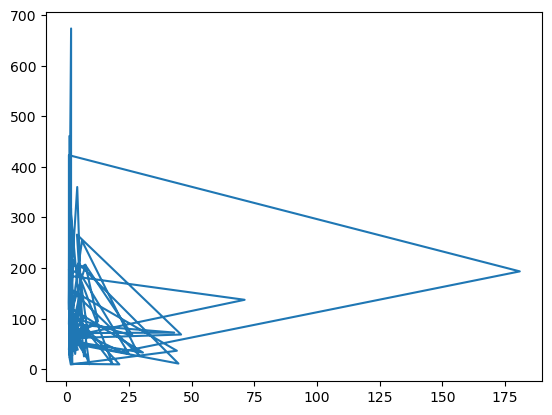

In [18]:
import matplotlib.pyplot as plt
import numpy as np
#Change dididends to 0 and 1
plt.plot(merged_df['score'], merged_df['current_value'])
#m, b = np.polyfit(merged_df['score'], merged_df['current_value'] , 1)
#plt.plot(merged_df['score'], m*merged_df['score']+b)
plt.show()